# Final MAD baseline

In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import polars.selectors as plselectors
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

import social_groups.polars_columns as plc
from social_groups.analysis.defs.notebooks.definitions import register_materialization
from social_groups.analysis.polars_transformations import (
    apply_parsing_and_group_decision,
)
from social_groups.analysis.polars_transformations.make_group_constellation import (
    parse_model_family,
)
from social_groups.polars_values import MODEL_NAME_TO_LETTER_MAPPING
from social_groups.reporting.decision_scheme_comparison import (
    log_likelihood_of_decision_scheme,
    wasserstein_transition_distance_to_optimal,
)
from social_groups.reporting.group_decision_scheme import (
    calculate_decision_scheme_matrix,
    calculate_empirical_decision_scheme,
    calculate_empirical_decision_scheme_matrix,
    calculate_extended_decision_scheme,
)
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
)
from social_groups.reporting.parsing import (
    AnswerComparer,
    AnswerOptions,
    AnswerParser,
)
from social_groups.reporting.theoretical_decision_schemes import (
    THEORETICAL_DECISION_SCHEMES,
)

%load_ext autoreload
%autoreload 2

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:398: BetaWarning: Class `Manager` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  MANAGER_FOR_NOTEBOOK_INSTANCE = Manager()
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:153: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:158: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterth

In [2]:
parser = AnswerParser(AnswerOptions.letters_A_to_J)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_J, triple_underscore_handling="wrong"
)

In [3]:
from social_groups.analysis.definitions import defs

frame: pl.DataFrame = defs().load_asset_value("final_changed_order_mad")
baseline: pl.DataFrame = defs().load_asset_value("final_baseline")

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_config/pythonic_config/typing_utils.py:101: UserWarning: Field name "extension" in "PolarsParquetIOManager" shadows an attribute in parent "BasePolarsUPathIOManager"
  return super().__new__(cls, name, bases, namespaces, **kwargs)
2026-05-11 10:16:38 -1000 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_changed_order_mad.parquet using PolarsParquetIOManager...
2026-05-11 10:16:40 -1000 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_baseline.parquet using PolarsParquetIOManager...


In [4]:
baseline_performance = (
    baseline.filter(pl.col("generation_method") == "standard")
    .filter(pl.col("with_few_shot_prompting") == True)
    .filter(pl.col("use_thinking") == True)
    .with_columns(
        comparer(parser(pl.col(plc.final_answer)), pl.col(plc.answer_string)).alias(
            plc.is_correct
        )
    )
    .group_by("model_name")
    .agg(
        pl.len(),
        pl.col(plc.is_correct).mean().alias(plc.accuracy),
        pl.col(plc.used_input_tokens).mean(),
        pl.col(plc.used_output_tokens).mean(),
    )
    .sort(plc.accuracy, descending=True)
    .with_columns(
        parse_model_family(pl.col("model_name")).alias(plc.model_family),
        pl.col("model_name")
        .replace(MODEL_NAME_TO_LETTER_MAPPING)
        .alias("model_letter"),
    )
)

assert baseline_performance["len"].unique().item() == 1000

baseline_performance = baseline_performance.drop("len")

baseline_performance

model_name,accuracy,used_input_tokens,used_output_tokens,model_family,model_letter
str,f64,f64,f64,str,str
"""Qwen/Qwen3-14B""",0.732,1359.15,1466.703,"""Qwen3""","""H"""
"""mistralai/Ministral-3-14B-Reas…",0.681,1346.492,502.132,"""Ministral""","""H"""
"""Qwen/Qwen3.5-9B""",0.645,1390.333,2924.042,"""Qwen3.5""","""H"""
"""mistralai/Ministral-3-8B-Reaso…",0.632,1346.492,570.057,"""Ministral""","""M"""
"""Qwen/Qwen3-4B""",0.631,1359.15,1592.183,"""Qwen3""","""M"""
"""Qwen/Qwen3.5-4B""",0.6,1390.333,3049.696,"""Qwen3.5""","""M"""
"""mistralai/Ministral-3-3B-Reaso…",0.436,1346.492,291.833,"""Ministral""","""L"""
"""Qwen/Qwen3-0.6B""",0.313,1359.15,1553.256,"""Qwen3""","""L"""
"""Qwen/Qwen3.5-0.8B""",0.128,1390.333,3952.648,"""Qwen3.5""","""L"""


In [5]:
mad_frame = apply_parsing_and_group_decision(frame, parser, comparer, group_reply)

In [6]:
frame2 = (
    mad_frame.group_by("model_family", plc.group_constellation)
    .agg(
        pl.len(),
        pl.col(plc.is_correct).mean().alias(plc.accuracy),
        pl.col(plc.used_input_tokens).mean(),
        pl.col(plc.used_output_tokens).mean(),
    )
    .sort(plc.accuracy, descending=True)
    .with_row_index("row_id")
    .with_columns(
        pl.col("group_constellation")
        .map_elements(list, return_dtype=pl.List(pl.String))
        .alias("letters")
    )
)

best = (
    frame2.explode("letters")
    .join(
        baseline_performance,
        left_on=["model_family", "letters"],
        right_on=["model_family", "model_letter"],
        how="left",
    )
    .group_by("row_id")
    .agg(pl.col("accuracy_right").max().alias("best_individual_performance"))
)
mad_performance = frame2.join(best, on="row_id").drop(["row_id", "letters"])
assert mad_performance["len"].unique().item() == 1000
mad_performance = mad_performance.drop("len").with_columns(
    (
        (pl.col(plc.accuracy) - pl.col("best_individual_performance")).alias(
            "group_increase"
        )
        * 100
    )
)
mad_performance.with_columns(
    (
        pl.when(pl.col(plc.group_constellation).str.ends_with("L"))
        .then(pl.lit(None))
        .otherwise(pl.col("group_increase"))
    ).alias("group_increase_no_last_L")
).filter(pl.col("group_increase_no_last_L").is_not_null()).head()

model_family,group_constellation,accuracy,used_input_tokens,used_output_tokens,best_individual_performance,group_increase,group_increase_no_last_L
str,str,f64,f64,f64,f64,f64,f64
"""Qwen3""","""MHH""",0.771,34322.547,8173.187,0.732,3.9,3.9
"""Qwen3""","""HMH""",0.767,34404.333,8279.762,0.732,3.5,3.5
"""Qwen3""","""HHH""",0.766,34570.127,8629.72,0.732,3.4,3.4
"""Qwen3""","""LHH""",0.766,34167.195,7903.707,0.732,3.4,3.4
"""Qwen3""","""HLH""",0.76,34549.506,8033.723,0.732,2.8,2.8


In [7]:
mad_performance.group_by("model_family").agg(
    pl.col("group_increase").mean().alias("group_increase_mean"),
    pl.col("group_increase").std().alias("group_increase_std"),
    pl.col("group_increase").median().alias("group_increase_median"),
    pl.col("group_increase").max().alias("group_increase_max"),
    pl.col("group_increase").min().alias("group_increase_min"),
)

model_family,group_increase_mean,group_increase_std,group_increase_median,group_increase_max,group_increase_min
str,f64,f64,f64,f64,f64
"""Ministral""",-6.388889,4.22846,-6.45,0.4,-17.7
"""Qwen3""",-3.902778,7.298003,-2.0,3.9,-21.7
"""Qwen3.5""",3.480556,5.528928,4.75,15.1,-9.7


### Decision Scheme Analysis

#### For One Case:

In [43]:
one_case_data = mad_frame.filter(pl.col("run_id") == 128)

print("Extended Decision Scheme Data:")
print(
    calculate_extended_decision_scheme(
        one_case_data,
        plc.parsed_individual_answers_before,
        plc.parsed_individual_answers_after,
        plc.answer_string,
        group_reply,
        comparer,
    )
)


emp_matrix = calculate_empirical_decision_scheme_matrix(
    one_case_data,
    plc.parsed_individual_answers_before,
    plc.parsed_individual_answers_after,
    plc.answer_string,
    group_reply,
    comparer,
)

print("Empirical Decision Scheme Matrix:")
print(emp_matrix)

matrix = calculate_decision_scheme_matrix(
    one_case_data,
    plc.parsed_individual_answers_before,
    plc.parsed_individual_answers_after,
    plc.answer_string,
    group_reply,
    comparer,
)
print("Decision Scheme Matrix:")
print(matrix)


print("Wasserstein Distance to Optimal: ")

print(wasserstein_transition_distance_to_optimal(matrix))

Extended Decision Scheme Data:
shape: (16, 5)
┌───────────────────────────┬─────────────────────┬─────────┬─────────────┬───────────┐
│ Correct Members Beginning ┆ Correct Members End ┆ correct ┆ occurrences ┆ incorrect │
│ ---                       ┆ ---                 ┆ ---     ┆ ---         ┆ ---       │
│ u32                       ┆ u32                 ┆ f64     ┆ u32         ┆ f64       │
╞═══════════════════════════╪═════════════════════╪═════════╪═════════════╪═══════════╡
│ 3                         ┆ 3                   ┆ 1.0     ┆ 152         ┆ 0.0       │
│ 3                         ┆ 2                   ┆ 1.0     ┆ 16          ┆ 0.0       │
│ 3                         ┆ 1                   ┆ 0.0     ┆ 1           ┆ 1.0       │
│ 3                         ┆ 0                   ┆ 0.0     ┆ 1           ┆ 1.0       │
│ 2                         ┆ 3                   ┆ 1.0     ┆ 63          ┆ 0.0       │
│ …                         ┆ …                   ┆ …       ┆ …           

In [42]:
one_case_data = mad_frame.filter(pl.col("run_id") == 148)

print("Extended Decision Scheme Data:")
print(
    calculate_extended_decision_scheme(
        one_case_data,
        plc.parsed_individual_answers_before,
        plc.parsed_individual_answers_after,
        plc.answer_string,
        group_reply,
        comparer,
    )
)


emp_matrix = calculate_empirical_decision_scheme_matrix(
    one_case_data,
    plc.parsed_individual_answers_before,
    plc.parsed_individual_answers_after,
    plc.answer_string,
    group_reply,
    comparer,
)

print("Empirical Decision Scheme Matrix:")
print(emp_matrix)

matrix = calculate_decision_scheme_matrix(
    one_case_data,
    plc.parsed_individual_answers_before,
    plc.parsed_individual_answers_after,
    plc.answer_string,
    group_reply,
    comparer,
)
print("Decision Scheme Matrix:")
print(matrix)


print("Wasserstein Distance to Optimal: ")

print(wasserstein_transition_distance_to_optimal(matrix))

Extended Decision Scheme Data:
shape: (14, 5)
┌───────────────────────────┬─────────────────────┬──────────┬─────────────┬───────────┐
│ Correct Members Beginning ┆ Correct Members End ┆ correct  ┆ occurrences ┆ incorrect │
│ ---                       ┆ ---                 ┆ ---      ┆ ---         ┆ ---       │
│ u32                       ┆ u32                 ┆ f64      ┆ u32         ┆ f64       │
╞═══════════════════════════╪═════════════════════╪══════════╪═════════════╪═══════════╡
│ 3                         ┆ 3                   ┆ 1.0      ┆ 153         ┆ 0.0       │
│ 3                         ┆ 2                   ┆ 1.0      ┆ 7           ┆ 0.0       │
│ 2                         ┆ 3                   ┆ 1.0      ┆ 120         ┆ 0.0       │
│ 2                         ┆ 2                   ┆ 1.0      ┆ 15          ┆ 0.0       │
│ 2                         ┆ 1                   ┆ 0.5      ┆ 10          ┆ 0.5       │
│ …                         ┆ …                   ┆ …        ┆ …

### For all groups

In [119]:
def temporary(filtered_frame: pl.DataFrame):
    matrix = calculate_decision_scheme_matrix(
        filtered_frame,
        plc.parsed_individual_answers_before,
        plc.parsed_individual_answers_after,
        plc.answer_string,
        group_reply,
        comparer,
    )

    filtered_frame = filtered_frame.with_columns(
        comparer(
            pl.col(plc.parsed_combined_answers_before),
            pl.col(plc.answer_string),
        ).alias("is_correct_before")
    )

    metadata = (
        filtered_frame.select(
            [
                name
                for name, is_constant in filtered_frame.select(pl.all().n_unique() == 1)
                .to_dicts()[0]
                .items()
                if is_constant
            ]
        )
        .unique()
        .to_dicts()[0]
    )

    for bias in ["good proposals", "bad proposals", "weight on one", False]:
        metadata[f"wd_bias_{bias}"] = wasserstein_transition_distance_to_optimal(
            matrix, biased=bias
        )

    metadata[plc.accuracy] = filtered_frame[plc.is_correct].mean()
    metadata["accuracy_before"] = filtered_frame["is_correct_before"].mean()
    metadata["accuracy_increase"] = metadata[plc.accuracy] - metadata["accuracy_before"]
    metadata["accuracy_increase_percent"] = (
        metadata[plc.accuracy] / metadata["accuracy_before"]
    ) - 1

    return pl.DataFrame([metadata])


wasserstein_mad = (
    mad_frame.group_by("run_id")
    .map_groups(temporary)
    .sort("wd_bias_False")
    .filter(pl.col(plc.group_constellation).str.len_chars() == 3)
)

wasserstein_mad = wasserstein_mad.join(
    mad_performance,
    on=["model_family", "group_constellation", "accuracy"],
    how="inner",
    validate="1:1",
).rename(
    {
        "best_individual_performance": "accuracy_best_individual_performance",
        "group_increase": "accuracy_group_increase",
    }
)

wasserstein_mad

run_id,run_identifier,model_names,group_constellation,model_family,wd_bias_good proposals,wd_bias_bad proposals,wd_bias_weight on one,wd_bias_False,accuracy,accuracy_before,accuracy_increase,accuracy_increase_percent,accuracy_best_individual_performance,accuracy_group_increase
i64,str,list[str],str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
151,"""2026-04-20-10-57-53 - changed_…","[""Qwen/Qwen3-4B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]","""MHH""","""Qwen3""",0.633072,1.563444,1.26743,1.098258,0.771,0.736,0.035,0.047554,0.732,3.9
169,"""2026-04-20-10-57-53 - changed_…","[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-4B"", ""Qwen/Qwen3-14B""]","""HMH""","""Qwen3""",0.735562,1.69064,1.48879,1.213101,0.767,0.747,0.02,0.026774,0.732,3.5
154,"""2026-04-20-10-57-53 - changed_…","[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]","""HHH""","""Qwen3""",0.845223,1.817514,1.737083,1.331369,0.766,0.749,0.017,0.022697,0.732,3.4
164,"""2026-04-20-10-57-53 - changed_…","[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]","""LHH""","""Qwen3""",0.678767,1.676932,1.551593,1.17785,0.766,0.734,0.032,0.043597,0.732,3.4
156,"""2026-04-20-10-57-53 - changed_…","[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B""]","""HLH""","""Qwen3""",0.664661,1.637193,1.488395,1.150927,0.76,0.718,0.042,0.058496,0.732,2.8
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
174,"""2026-04-20-10-57-53 - changed_…","[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-4B"", ""Qwen/Qwen3-0.6B""]","""LML""","""Qwen3""",0.847713,1.68009,1.336699,1.263901,0.477,0.35,0.127,0.362857,0.631,-15.4
159,"""2026-04-20-10-57-53 - changed_…","[""Qwen/Qwen3-4B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B""]","""MLL""","""Qwen3""",0.871071,1.728361,1.431047,1.299716,0.463,0.357,0.106,0.296919,0.631,-16.8
106,"""2026-04-23-07-09-54 - changed_…","[""mistralai/Ministral-3-3B-Reasoning-2512"", ""mistralai/Ministral-3-3B-Reasoning-2512"", ""mistralai/Ministral-3-3B-Reasoning-2512""]","""LLL""","""Ministral""",1.062732,1.952993,1.802097,1.507863,0.393,0.42,-0.027,-0.064286,0.436,-4.3


In [112]:
mad_corr = wasserstein_mad.select(
    plselectors.starts_with("wd_bias"), plselectors.starts_with("accuracy")
).corr()

mad_corr

wd_bias_good proposals,wd_bias_bad proposals,wd_bias_weight on one,wd_bias_False,accuracy,accuracy_before,accuracy_increase,accuracy_increase_percent,accuracy_best_individual_performance,accuracy_group_increase
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,0.842072,0.736798,0.959027,-0.571612,-0.060788,-0.623348,-0.563111,-0.398413,-0.284134
0.842072,1.0,0.883957,0.960379,-0.522695,0.08832,-0.790335,-0.707771,-0.244352,-0.407397
0.736798,0.883957,1.0,0.845029,-0.332139,0.247952,-0.795912,-0.759781,-0.24106,-0.153339
0.959027,0.960379,0.845029,1.0,-0.569915,0.014982,-0.737231,-0.662737,-0.334216,-0.360809
-0.571612,-0.522695,-0.332139,-0.569915,1.0,0.759539,0.090421,-0.012537,0.704569,0.487762
-0.060788,0.08832,0.247952,0.014982,0.759539,1.0,-0.579118,-0.649029,0.538012,0.366951
-0.623348,-0.790335,-0.795912,-0.737231,0.090421,-0.579118,1.0,0.977998,0.059322,0.049499
-0.563111,-0.707771,-0.759781,-0.662737,-0.012537,-0.649029,0.977998,1.0,0.039233,-0.065244
-0.398413,-0.244352,-0.24106,-0.334216,0.704569,0.538012,0.059322,0.039233,1.0,-0.275833


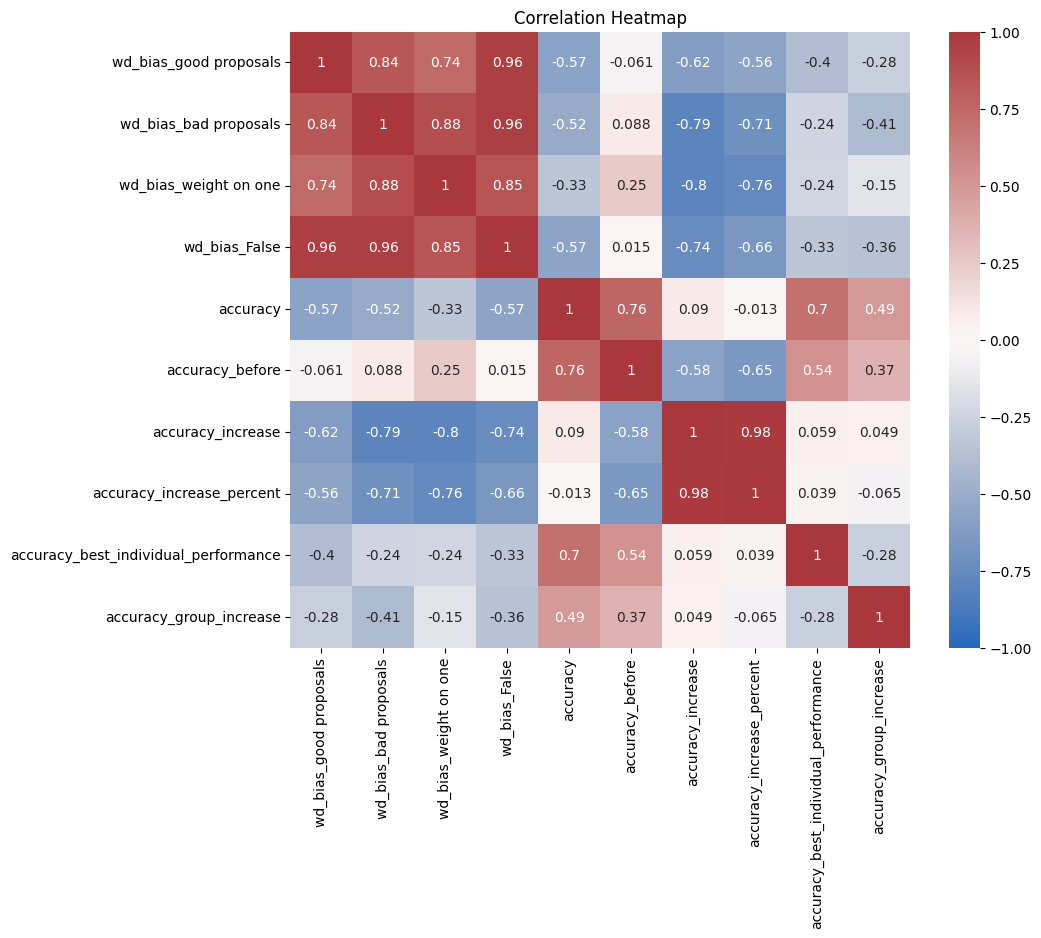

In [113]:
plt.figure(figsize=(10, 8))

df = mad_corr.to_pandas()

df.index = mad_corr.columns
sns.heatmap(df, annot=True, cmap="vlag", vmin=-1, vmax=1)

plt.title("Correlation Heatmap")

plt.show()

Using:  ['wd_bias_good proposals', 'wd_bias_bad proposals', 'wd_bias_weight on one', 'wd_bias_False', 'group_constellation', 'model_family', 'accuracy_increase_percent', 'accuracy_before']

=== Decision Tree Rules ===

|--- wd_bias_bad proposals <= 1.43
|   |--- value: [0.65]
|--- wd_bias_bad proposals >  1.43
|   |--- accuracy_before <= 0.51
|   |   |--- wd_bias_good proposals <= 1.00
|   |   |   |--- value: [0.37]
|   |   |--- wd_bias_good proposals >  1.00
|   |   |   |--- value: [0.09]
|   |--- accuracy_before >  0.51
|   |   |--- wd_bias_bad proposals <= 1.61
|   |   |   |--- value: [0.15]
|   |   |--- wd_bias_bad proposals >  1.61
|   |   |   |--- wd_bias_bad proposals <= 1.74
|   |   |   |   |--- value: [0.05]
|   |   |   |--- wd_bias_bad proposals >  1.74
|   |   |   |   |--- value: [-0.01]



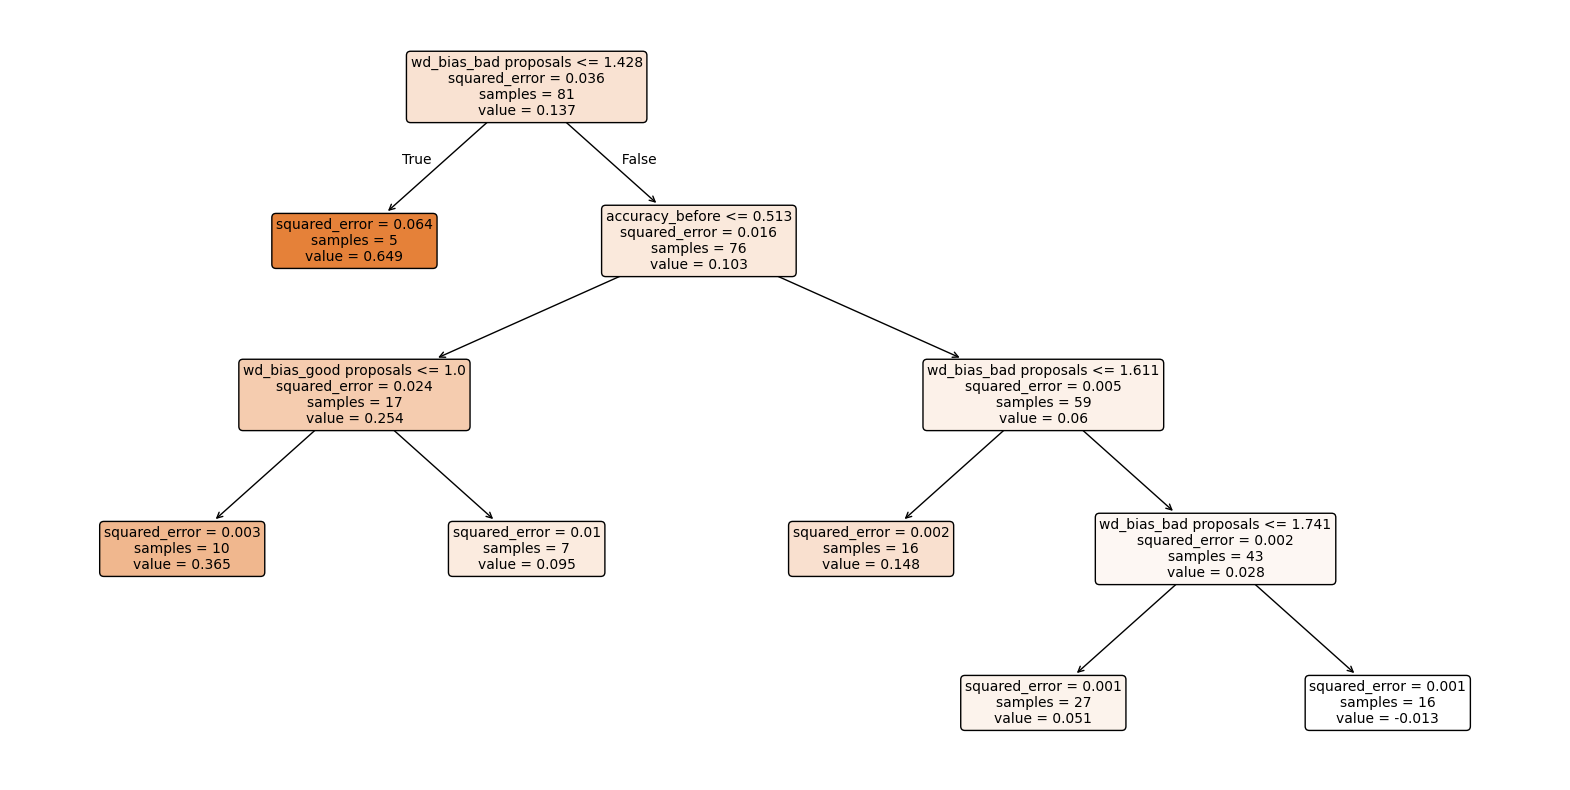


=== Names per leaf ===


Leaf 1
Names: ['LMH', 'LLH', 'LLH', 'LLM', 'LLM']
families: {5: 'Qwen3', 9: 'Qwen3.5', 15: 'Qwen3', 26: 'Qwen3.5', 55: 'Qwen3'}
Mean target: 0.6492335661900656

Leaf 5
Names: ['LLH', 'LHL', 'LHL', 'LML', 'HLL', 'MLL', 'LHL', 'HLL', 'LML', 'MLL']
families: {54: 'Ministral', 59: 'Qwen3.5', 60: 'Ministral', 65: 'Qwen3.5', 68: 'Qwen3.5', 71: 'Qwen3.5', 72: 'Qwen3', 74: 'Qwen3', 76: 'Qwen3', 77: 'Qwen3'}
Mean target: 0.36506238492433996

Leaf 6
Names: ['HLL', 'LML', 'LLM', 'MLL', 'LLL', 'LLL', 'LLL']
families: {64: 'Ministral', 67: 'Ministral', 70: 'Ministral', 75: 'Ministral', 78: 'Ministral', 79: 'Qwen3', 80: 'Qwen3.5'}
Mean target: 0.09478170716478515

Leaf 7
Names: ['MHH', 'MLH', 'MMH', 'MLH', 'HLM', 'HLH', 'LMH', 'LHH', 'MMH', 'MHL', 'LHM', 'HHL', 'HML', 'MLM', 'LMM', 'MML']
families: {0: 'Qwen3', 6: 'Qwen3', 8: 'Qwen3', 10: 'Qwen3.5', 11: 'Qwen3.5', 12: 'Qwen3.5', 16: 'Qwen3.5', 17: 'Qwen3.5', 19: 'Qwen3.5', 20: 'Qwen3.5', 23: 'Qwen3.5', 28: 'Qwen3.5', 34: 'Q

In [115]:
# ====== CONFIG ======
target_col = "accuracy_increase_percent"
name_col = plc.group_constellation
family_col = plc.model_family


df = wasserstein_mad.select(plselectors.numeric(), name_col, family_col).select(
    pl.exclude("^accuracy.*$", target_col, "run_id"), target_col, "accuracy_before"
)

print("Using: ", df.columns)

# ====== DATA PREP (Polars → Pandas) ======
X = df.drop(target_col, name_col, family_col).to_pandas()
y = df[target_col].to_pandas()
names = df.select(name_col).to_pandas()[name_col]
families = df.select(family_col).to_pandas()[family_col]

# ====== FIT INTERPRETABLE TREE ======
model = DecisionTreeRegressor(
    max_leaf_nodes=6,  # keep small for interpretability (3–5 recommended)
    random_state=42,
    min_samples_leaf=5,
)

model.fit(X, y)

# ====== PRINT RULES ======
print("\n=== Decision Tree Rules ===\n")
rules = export_text(model, feature_names=list(X.columns))
print(rules)

# ====== PLOT TREE ======
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.show()

# ===== ASSIGN LEAVES =====

leaf_ids = model.apply(X)


# Attach everything into a dataframe
df_leaves = pd.DataFrame(
    {"leaf": leaf_ids, "name": names, "target": y, "family": families}
)
# ===== PRINT NAMES PER LEAF =====
print("\n=== Names per leaf ===\n")
for leaf, group in df_leaves.groupby("leaf"):
    print(f"\nLeaf {leaf}")
    print("Names:", group["name"].to_list())
    print("families:", group["family"].to_dict())
    print("Mean target:", group["target"].mean())

## Decision Scheme Analysis

### For One

In [128]:
one_case_data = mad_frame.filter(pl.col("run_id") == 133)

emp_matrix = calculate_empirical_decision_scheme(
    one_case_data,
    plc.parsed_individual_answers_before,
    plc.parsed_individual_answers_after,
    plc.answer_string,
    group_reply,
    comparer,
)

print("Empirical Decision Scheme:")
print(emp_matrix)

print("Comparison to other decision schemes")

for name, s in THEORETICAL_DECISION_SCHEMES.items():
    ll = log_likelihood_of_decision_scheme(emp_matrix, s, epsilon=0.05)
    print(f"{name}", ll)

Empirical Decision Scheme:
shape: (4, 3)
┌─────────┬───────────┬───────────────────────────┐
│ correct ┆ incorrect ┆ Correct Members Beginning │
│ ---     ┆ ---       ┆ ---                       │
│ i64     ┆ i64       ┆ u32                       │
╞═════════╪═══════════╪═══════════════════════════╡
│ 15      ┆ 590       ┆ 0                         │
│ 51      ┆ 93        ┆ 1                         │
│ 63      ┆ 30        ┆ 2                         │
│ 150     ┆ 8         ┆ 3                         │
└─────────┴───────────┴───────────────────────────┘
Comparison to other decision schemes
proportionality -14.398370339520632
majority_rule -112.81428617486124
truth_wins -236.4807232998516
truth_supported -112.81428617486124
unanimity -209.98077248735376
random_rule -448.44651851394616
incorrect_wins -2321.143520549691
minority_wins -2347.643471362189


In [135]:
def temporary(filtered_frame: pl.DataFrame):
    emp_matrix = calculate_empirical_decision_scheme(
        filtered_frame,
        plc.parsed_individual_answers_before,
        plc.parsed_individual_answers_after,
        plc.answer_string,
        group_reply,
        comparer,
    )

    filtered_frame = filtered_frame.with_columns(
        comparer(
            pl.col(plc.parsed_combined_answers_before),
            pl.col(plc.answer_string),
        ).alias("is_correct_before")
    )

    metadata = (
        filtered_frame.select(
            [
                name
                for name, is_constant in filtered_frame.select(pl.all().n_unique() == 1)
                .to_dicts()[0]
                .items()
                if is_constant
            ]
        )
        .unique()
        .to_dicts()[0]
    )

    for name, s in THEORETICAL_DECISION_SCHEMES.items():
        metadata[f"ll_{name}"] = log_likelihood_of_decision_scheme(
            emp_matrix, s, epsilon=0.05
        )
    metadata["best_fitting_ds"] = max(
        filter(lambda key: key.startswith("ll_"), metadata),
        key=lambda key: metadata[key],
    ).replace("ll_", "")

    metadata[plc.accuracy] = filtered_frame[plc.is_correct].mean()
    metadata["accuracy_before"] = filtered_frame["is_correct_before"].mean()
    metadata["accuracy_increase"] = metadata[plc.accuracy] - metadata["accuracy_before"]
    metadata["accuracy_increase_percent"] = (
        metadata[plc.accuracy] / metadata["accuracy_before"]
    ) - 1

    return pl.DataFrame([metadata])


decision_scheme_mad = mad_frame.group_by("run_id").map_groups(temporary)

decision_scheme_mad = decision_scheme_mad.join(
    mad_performance,
    on=["model_family", "group_constellation", "accuracy"],
    how="inner",
    validate="1:1",
).rename(
    {
        "best_individual_performance": "accuracy_best_individual_performance",
        "group_increase": "accuracy_group_increase",
    }
)

decision_scheme_mad.select("best_fitting_ds", pl.exclude("best_fitting_ds")).sort(
    "accuracy"
)

best_fitting_ds,run_id,run_identifier,model_names,group_constellation,model_family,ll_proportionality,ll_majority_rule,ll_truth_wins,ll_truth_supported,ll_unanimity,ll_random_rule,ll_incorrect_wins,ll_minority_wins,accuracy,accuracy_before,accuracy_increase,accuracy_increase_percent,accuracy_best_individual_performance,accuracy_group_increase
str,i64,str,list[str],str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""proportionality""",191,"""2026-04-18-09-18-49 - changed_…","[""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-0.8B""]","""LL""","""Qwen3.5""",-11.931953,-11.931953,-119.34982,-137.016454,-137.016454,-490.31532,-2522.012027,-2504.345393,0.276,0.259,0.017,0.065637,0.128,14.8
"""proportionality""",200,"""2026-04-20-10-57-39 - changed_…","[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B""]","""LL""","""Qwen3""",-31.236229,-31.236229,-155.108771,-196.330917,-196.330917,-322.907982,-2151.438399,-2110.216253,0.278,0.212,0.066,0.311321,0.313,-3.5
"""proportionality""",133,"""2026-04-18-17-47-52 - changed_…","[""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-0.8B""]","""LLL""","""Qwen3.5""",-14.39837,-112.814286,-236.480723,-112.814286,-209.980772,-448.446519,-2321.143521,-2347.643471,0.279,0.296,-0.017,-0.057432,0.128,15.1
"""proportionality""",160,"""2026-04-20-10-57-53 - changed_…","[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B""]","""LLL""","""Qwen3""",-34.929433,-174.854077,-204.298467,-174.854077,-316.187148,-298.486703,-2053.406146,-1941.517465,0.303,0.268,0.035,0.130597,0.313,-1.0
"""proportionality""",106,"""2026-04-23-07-09-54 - changed_…","[""mistralai/Ministral-3-3B-Reasoning-2512"", ""mistralai/Ministral-3-3B-Reasoning-2512"", ""mistralai/Ministral-3-3B-Reasoning-2512""]","""LLL""","""Ministral""",-22.751312,-63.801013,-116.800915,-63.801013,-169.800816,-464.210903,-2472.352098,-2419.352196,0.393,0.42,-0.027,-0.064286,0.436,-4.3
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""truth_wins""",156,"""2026-04-20-10-57-53 - changed_…","[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B""]","""HLH""","""Qwen3""",-204.473813,-111.138318,-105.24944,-111.138318,-1521.524589,-567.492548,-2690.466864,-1274.191715,0.76,0.718,0.042,0.058496,0.732,2.8
"""proportionality""",154,"""2026-04-20-10-57-53 - changed_…","[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]","""HHH""","""Qwen3""",-46.474847,-76.59765,-111.930918,-76.59765,-188.486331,-580.062904,-2708.926097,-2632.370684,0.766,0.749,0.017,0.022697,0.732,3.4
"""majority_rule""",164,"""2026-04-20-10-57-53 - changed_…","[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]","""LHH""","""Qwen3""",-193.476214,-105.249996,-111.138874,-105.249996,-1512.691828,-558.659788,-2666.911908,-1265.358954,0.766,0.734,0.032,0.043597,0.732,3.4


## Change in Order

In [ ]:
mad_performance.drop("group_increase").schema

In [ ]:
df_with_composition = mad_performance.with_columns(
    pl.col("group_constellation")
    .map_elements(lambda s: "".join(sorted(s)), return_dtype=pl.String)
    .alias("group_composition")
)

In [ ]:
order_effects = df_with_composition.group_by(
    ["model_family", "group_composition", "group_constellation"]
).agg(
    [
        pl.mean("accuracy").alias("mean_accuracy"),
        pl.std("accuracy").alias("std_accuracy"),
        pl.len().alias("n"),
        pl.mean("best_individual_performance").alias("mean_best_individual"),
    ]
)

assert order_effects["n"].unique().item() == 1

order_effects = df_with_composition.sort(
    ["model_family", "group_composition", "accuracy"],
    descending=[False, False, True],
)

print("\n=== order effects within same composition ===")
order_effects.head()

In [ ]:
permutation_spread = (
    order_effects.group_by(["model_family", "group_composition"])
    .agg(
        [
            pl.max("accuracy").alias("best_perm"),
            pl.min("accuracy").alias("worst_perm"),
            (pl.max("accuracy") - pl.min("accuracy")).alias("spread"),
            pl.std("accuracy").alias("perm_std"),
            pl.len().alias("num_permutations"),
        ]
    )
    .sort("spread", descending=True)
)

print("\n=== PERMUTATION SPREAD ===")
permutation_spread

In [ ]:
# ============================================================
# 4. Which POSITION matters?
#
#    Example questions:
#      - Is H strongest in position 1?
#      - Is M bad in the middle?
#
#    We explode each string into positional columns.
# ============================================================

max_len = df_with_composition.select(
    pl.col("group_constellation").str.len_chars().max()
).item()

# Create position columns
for i in range(max_len):
    df_with_composition = df_with_composition.with_columns(
        pl.col("group_constellation").str.slice(i, 1).alias(f"pos_{i + 1}")
    )

# Analyze position effects
position_effects = (
    df_with_composition.unpivot(
        index=["model_family", "accuracy", "best_individual_performance"],
        on=[f"pos_{i + 1}" for i in range(max_len)],
        variable_name="position",
        value_name="member",
    )
    .group_by(["model_family", "position", "member"])
    .agg(
        [
            pl.mean("accuracy").alias("mean_accuracy"),
            pl.std("accuracy").alias("std_accuracy"),
            pl.len().alias("n"),
        ]
    )
    .sort(
        ["model_family", "position", "mean_accuracy"], descending=[False, False, True]
    )
)

print("\n=== POSITION EFFECTS ===")
print(position_effects)


# ============================================================
# 5. FAMILY DIFFERENCES
#
#    Compare families overall.
# ============================================================

family_summary = (
    df_with_composition.group_by("model_family")
    .agg(
        [
            pl.mean("accuracy").alias("mean_accuracy"),
            pl.std("accuracy").alias("std_accuracy"),
            pl.mean("best_individual_performance").alias("mean_best_individual"),
            pl.len().alias("n"),
        ]
    )
    .sort("mean_accuracy", descending=True)
)

print("\n=== FAMILY SUMMARY ===")
print(family_summary)


# ============================================================
# 6. FAMILY x COMPOSITION interaction
#
#    Which family handles which group_compositions best?
# ============================================================

family_group_composition = (
    df_with_composition.group_by(["model_family", "group_composition"])
    .agg(
        [
            pl.mean("accuracy").alias("mean_accuracy"),
            pl.std("accuracy").alias("std_accuracy"),
            pl.len().alias("n"),
        ]
    )
    .sort(["group_composition", "mean_accuracy"], descending=[False, True])
)

print("\n=== FAMILY x COMPOSITION ===")
print(family_group_composition)


# ============================================================
# 7. Pairwise permutation comparisons
#
#    Directly compare permutations of same group_composition.
#
#    Example:
#      HML - HLM = +0.03
# ============================================================

pairwise_rows = []

for (family, comp), group in order_effects.group_by(
    ["model_family", "group_composition"]
):
    rows = group.to_dicts()

    for a, b in combinations(rows, 2):
        diff = a["mean_accuracy"] - b["mean_accuracy"]

        pairwise_rows.append(
            {
                "model_family": family,
                "group_composition": comp,
                "perm_a": a["group_constellation"],
                "perm_b": b["group_constellation"],
                "accuracy_diff": diff,
                "abs_diff": abs(diff),
            }
        )

pairwise_df = pl.DataFrame(pairwise_rows).sort("abs_diff", descending=True)

print("\n=== PAIRWISE PERMUTATION DIFFERENCES ===")
print(pairwise_df)


# ============================================================
# 8. Optional:
#    Simple "does order matter?" score
#
#    Ratio:
#      variation BETWEEN permutations
#      --------------------------------
#      total variation
# ============================================================

overall_std = df_with_composition.select(pl.std("accuracy")).item()

spread_score = permutation_spread.with_columns(
    (pl.col("spread") / overall_std).alias("normalized_order_effect")
).sort("normalized_order_effect", descending=True)

print("\n=== NORMALIZED ORDER EFFECT ===")
print(spread_score)

In [ ]:
register_materialization(USED_NAME, SOME_DATA, SOME_DESCRIPTION)